In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter

DATA_DIR  = r"D:\dcgan\data\ham10000"
META_CSV  = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
IMG_DIRS  = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_FULL  = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions'
}

meta = pd.read_csv(META_CSV)
print(f"Dataset shape: {meta.shape}")
print(meta.head())

Dataset shape: (10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


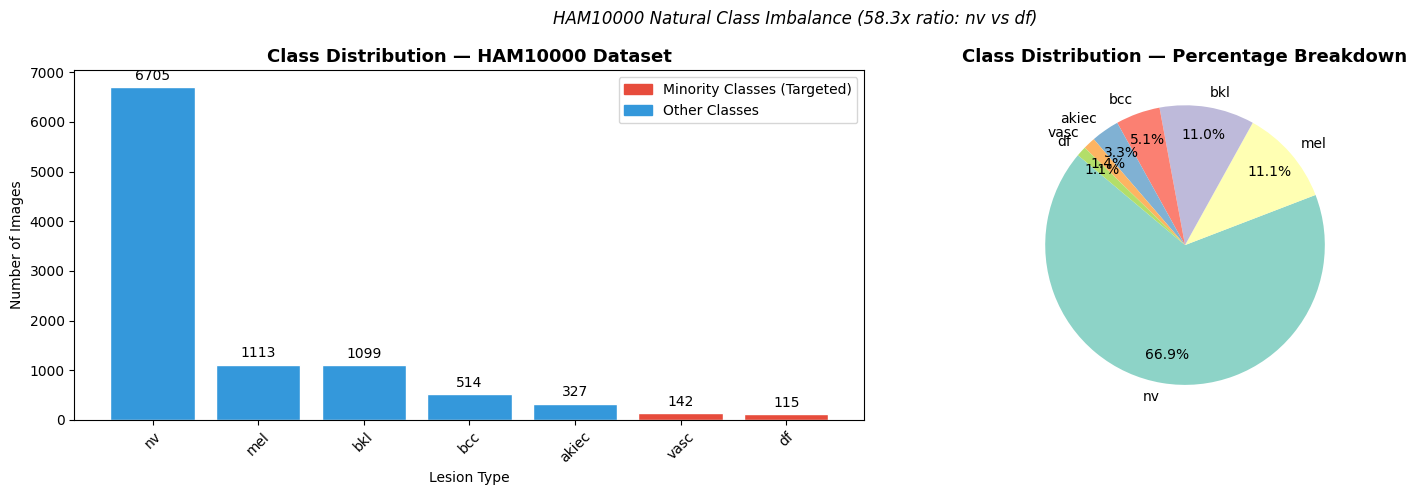


Class counts:
  nv       (Melanocytic Nevi         ):  6705 samples  (1.0x fewer than nv)
  mel      (Melanoma                 ):  1113 samples  (6.0x fewer than nv)
  bkl      (Benign Keratosis         ):  1099 samples  (6.1x fewer than nv)
  bcc      (Basal Cell Carcinoma     ):   514 samples  (13.0x fewer than nv)
  akiec    (Actinic Keratoses        ):   327 samples  (20.5x fewer than nv)
  vasc     (Vascular Lesions         ):   142 samples  (47.2x fewer than nv)
  df       (Dermatofibroma           ):   115 samples  (58.3x fewer than nv)


In [2]:
counts = meta['dx'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#e74c3c' if c in ['df', 'vasc'] else '#3498db' for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_title("Class Distribution — HAM10000 Dataset", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Lesion Type")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=45)
minority_patch = mpatches.Patch(color='#e74c3c', label='Minority Classes (Targeted)')
majority_patch = mpatches.Patch(color='#3498db', label='Other Classes')
axes[0].legend(handles=[minority_patch, majority_patch])

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=plt.cm.Set3.colors[:len(counts)],
            startangle=140, pctdistance=0.8)
axes[1].set_title("Class Distribution — Percentage Breakdown", fontsize=13, fontweight='bold')

plt.suptitle("HAM10000 Natural Class Imbalance (58.3x ratio: nv vs df)",
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

print("\nClass counts:")
for cls, count in counts.items():
    full = CLASS_FULL.get(cls, cls)
    ratio = counts['nv'] / count
    print(f"  {cls:8s} ({full:25s}): {count:5d} samples  ({ratio:.1f}x fewer than nv)")

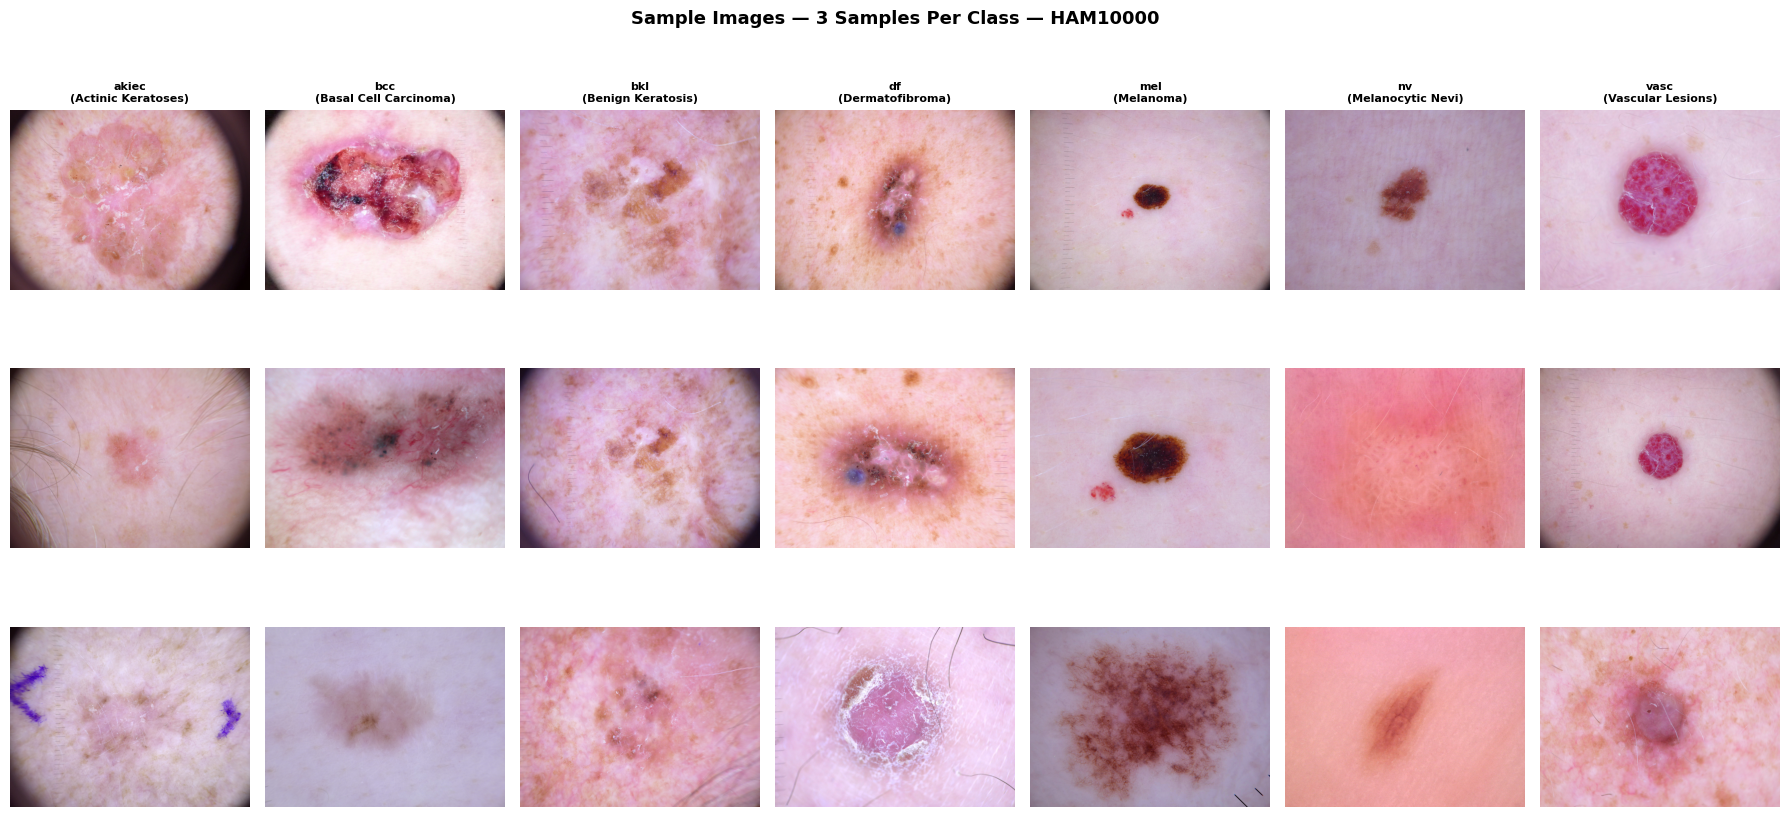

In [3]:
def build_lookup(img_dirs):
    lookup = {}
    for folder in img_dirs:
        for fname in os.listdir(folder):
            if fname.endswith('.jpg'):
                lookup[fname.replace('.jpg', '')] = os.path.join(folder, fname)
    return lookup

image_lookup = build_lookup(IMG_DIRS)

fig, axes = plt.subplots(3, 7, figsize=(18, 9))

for col, cls in enumerate(CLASS_NAMES):
    class_rows = meta[meta['dx'] == cls]
    for row in range(3):
        img_id  = class_rows.iloc[row]['image_id']
        img     = Image.open(image_lookup[img_id]).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(f"{cls}\n({CLASS_FULL[cls]})",
                                     fontsize=8, fontweight='bold')

plt.suptitle("Sample Images — 3 Samples Per Class — HAM10000",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Manas\AppData\Local\Temp\ipykernel_41036\1271984295.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(age_data, labels=CLASS_NAMES, patch_artist=True)


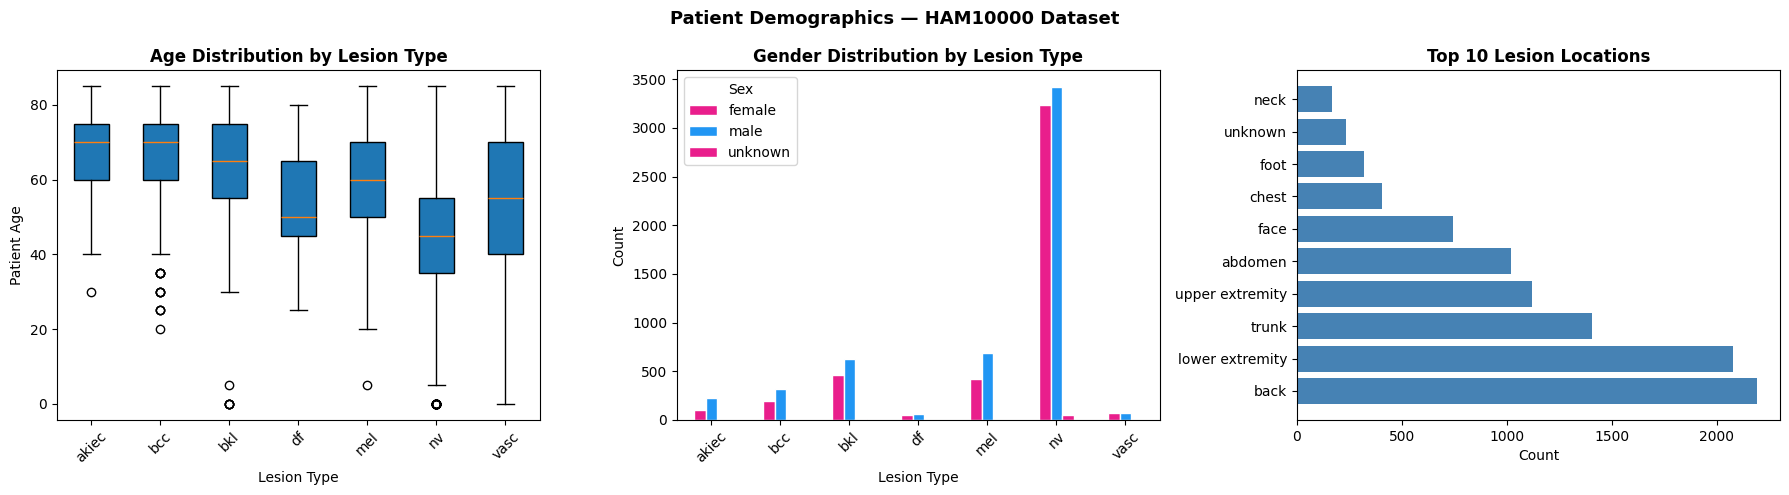

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution per class
age_data = [meta[meta['dx'] == cls]['age'].dropna().values for cls in CLASS_NAMES]
axes[0].boxplot(age_data, labels=CLASS_NAMES, patch_artist=True)
axes[0].set_title("Age Distribution by Lesion Type", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Lesion Type")
axes[0].set_ylabel("Patient Age")
axes[0].tick_params(axis='x', rotation=45)

# Gender distribution per class
gender_counts = meta.groupby(['dx', 'sex']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=axes[1], color=['#e91e8c', '#2196f3'],
                   edgecolor='white')
axes[1].set_title("Gender Distribution by Lesion Type", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Lesion Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Sex")

# Localization distribution
loc_counts = meta['localization'].value_counts().head(10)
axes[2].barh(loc_counts.index, loc_counts.values, color='steelblue')
axes[2].set_title("Top 10 Lesion Locations", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Count")

plt.suptitle("Patient Demographics — HAM10000 Dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

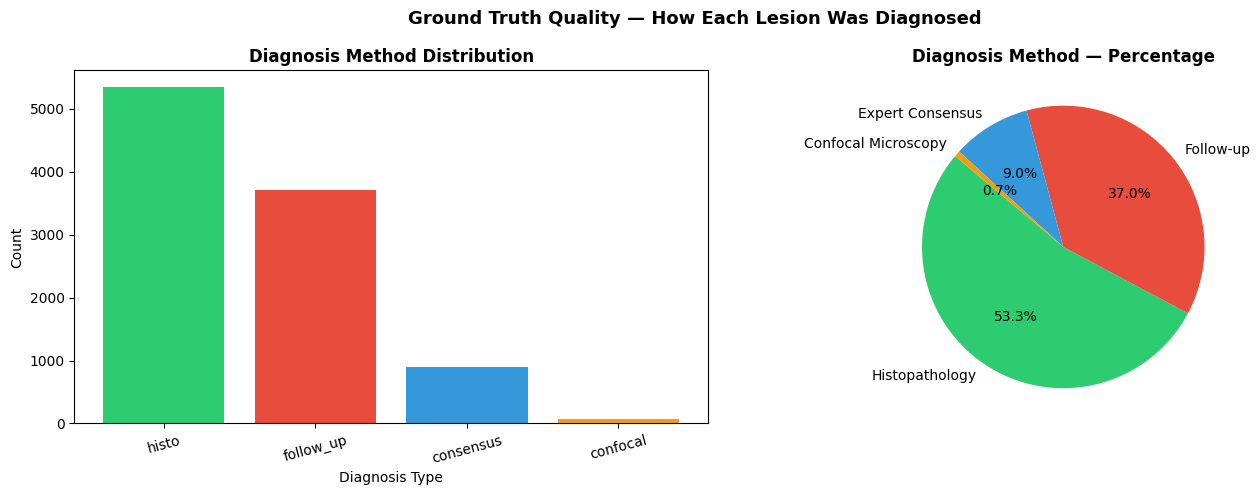

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dx_type_counts = meta['dx_type'].value_counts()
axes[0].bar(dx_type_counts.index, dx_type_counts.values,
            color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
axes[0].set_title("Diagnosis Method Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Diagnosis Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=15)

dx_type_labels = {
    'histo':   'Histopathology',
    'follow_up': 'Follow-up',
    'consensus': 'Expert Consensus',
    'confocal': 'Confocal Microscopy'
}
axes[1].pie(dx_type_counts.values,
            labels=[dx_type_labels.get(x, x) for x in dx_type_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
axes[1].set_title("Diagnosis Method — Percentage", fontsize=12, fontweight='bold')

plt.suptitle("Ground Truth Quality — How Each Lesion Was Diagnosed",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Computing pixel statistics per class (sampling 30 images per class)...


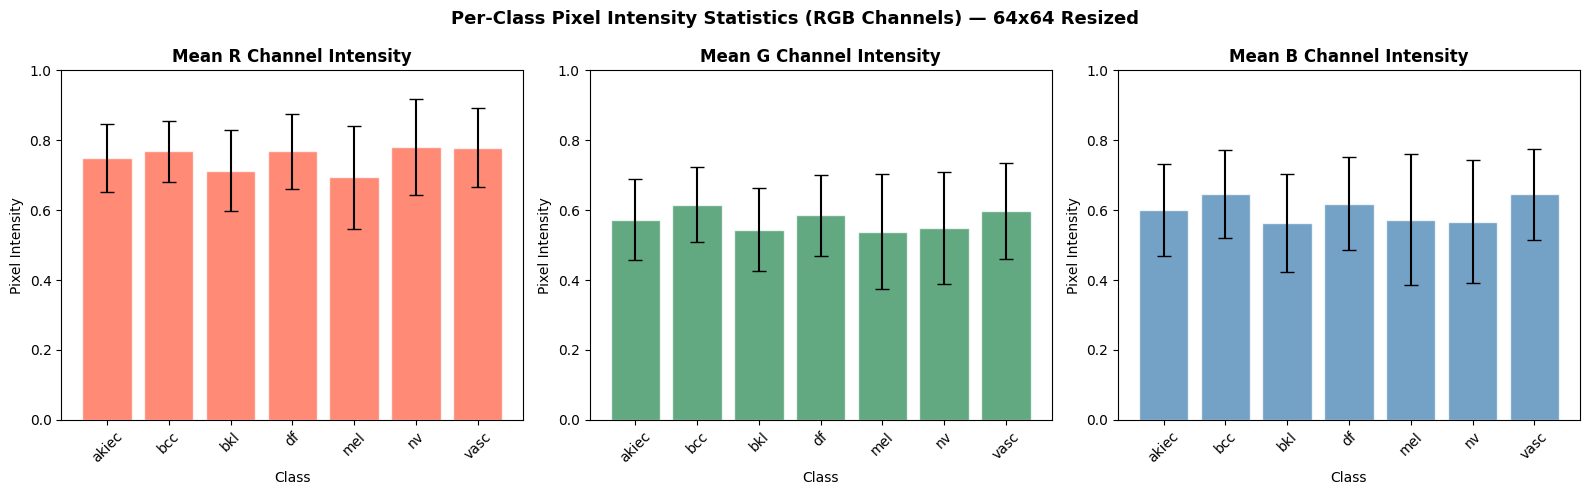

In [6]:
from torchvision import transforms

transform_eda = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

print("Computing pixel statistics per class (sampling 30 images per class)...")
stats = {}
for cls in CLASS_NAMES:
    class_rows = meta[meta['dx'] == cls].sample(min(30, len(meta[meta['dx'] == cls])),
                                                  random_state=42)
    pixels = []
    for _, row in class_rows.iterrows():
        img = Image.open(image_lookup[row['image_id']]).convert('RGB')
        t   = transform_eda(img).numpy()
        pixels.append(t)
    pixels = np.array(pixels)
    stats[cls] = {
        'mean_r': pixels[:, 0].mean(), 'std_r': pixels[:, 0].std(),
        'mean_g': pixels[:, 1].mean(), 'std_g': pixels[:, 1].std(),
        'mean_b': pixels[:, 2].mean(), 'std_b': pixels[:, 2].std(),
    }

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels  = [('R', 'mean_r', 'std_r', 'tomato'),
             ('G', 'mean_g', 'std_g', 'seagreen'),
             ('B', 'mean_b', 'std_b', 'steelblue')]

for ax, (ch_name, mean_key, std_key, color) in zip(axes, channels):
    means = [stats[c][mean_key] for c in CLASS_NAMES]
    stds  = [stats[c][std_key]  for c in CLASS_NAMES]
    ax.bar(CLASS_NAMES, means, yerr=stds, capsize=5, color=color,
           alpha=0.75, edgecolor='white')
    ax.set_title(f"Mean {ch_name} Channel Intensity", fontsize=12, fontweight='bold')
    ax.set_xlabel("Class")
    ax.set_ylabel("Pixel Intensity")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1.0)

plt.suptitle("Per-Class Pixel Intensity Statistics (RGB Channels) — 64x64 Resized",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
summary = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Full Name': [CLASS_FULL[c] for c in CLASS_NAMES],
    'Total Samples': [len(meta[meta['dx'] == c]) for c in CLASS_NAMES],
    'Train Samples': [len(meta[meta['dx'] == c]) * 4 // 5 for c in CLASS_NAMES],
    'Test Samples':  [len(meta[meta['dx'] == c]) * 1 // 5 for c in CLASS_NAMES],
    'Imbalance Ratio vs nv': [
        f"{len(meta[meta['dx'] == 'nv']) / len(meta[meta['dx'] == c]):.1f}x"
        for c in CLASS_NAMES
    ],
    'GAN Strategy': [
        'Transfer GAN (target)' if c in ['df', 'vasc'] else 'Not augmented'
        for c in CLASS_NAMES
    ]
})

print("=" * 90)
print("HAM10000 Class Distribution Summary")
print("=" * 90)
print(summary.to_string(index=False))
print("=" * 90)

HAM10000 Class Distribution Summary
Class            Full Name  Total Samples  Train Samples  Test Samples Imbalance Ratio vs nv          GAN Strategy
akiec    Actinic Keratoses            327            261            65                 20.5x         Not augmented
  bcc Basal Cell Carcinoma            514            411           102                 13.0x         Not augmented
  bkl     Benign Keratosis           1099            879           219                  6.1x         Not augmented
   df       Dermatofibroma            115             92            23                 58.3x Transfer GAN (target)
  mel             Melanoma           1113            890           222                  6.0x         Not augmented
   nv     Melanocytic Nevi           6705           5364          1341                  1.0x         Not augmented
 vasc     Vascular Lesions            142            113            28                 47.2x Transfer GAN (target)
